# Kaplan Meier Algorithm

In [1]:
# The Kaplan Meier algorithm computes a Kaplan Meier estimate for the survival function. 
# I suggest to have a brief look at the swimlane diagram:
# https://algorithms.vantage6.ai/en/latest/v6-kaplan-meier-py/docs/v6-kaplan-meier-py/implementation.html
# to have a good overview of the different steps in the algorithm. From the diagram
# you can see that this is a one (federated-)step algorithm:
#
# 1. Call `get_unique_event_times`
# 2. Call `get_km_event_table`
#
# And then there is the central part responsible for the aggregation of the results. The
# central part of the algorithm (the main call) will return the Kaplan Meier estimate for
# the entire federated dataset. 
#
# 1. Create a new vantage6 task to execute the *kaplan_meier_central* method (central 
#    part). This central part will start the tasks `get_unique_event_times` and
#    `get_km_event_table` (as you can see in the swimlane diagram).
# 2. Poll until the task is finished
# 3. Retrieve the *global* Kaplan Meier estimate from the central part (the main call)

In [2]:
import base64
import json
import requests

In [3]:
with open("token.txt", "r") as f:
    token = f.read().strip()
headers = {
    "Authorization": token
}

In [4]:
# Set the collaboration ID:
#
#   - 2: Test collaboration (with IKNL and UPM)
#   - 3: IDEA4RC collaboration
#
COLLABORATION_ID = 2

In [5]:
# Set the organization IDs that are part of this workspace. These should be the IDs of
# the vantage6 organizations:
#
#   1	- root
#   2	- ENG
#   3	- UPM
#   4	- INT
#   5	- UKE
#   6	- CLB
#   7	- FPNS
#
# These are basically all organization that are part of the workspace (thus the same
# list as in the `1-new-workspace.ipynb` notebook):
response = requests.get(
    f"https://vantage6-core.orchestrator.idea.lst.tfo.upm.es/server/organization?collaboration_id={COLLABORATION_ID}",
    headers=headers
)
ORGANIZATION_IDS = [org["id"] for org in response.json()["data"]]
ORGANIZATION_IDS

[1, 3]

In [6]:
# Set the study ID. This is the `study` id that belongs to the RAVEN workspace. See the
# `0-new-workspace.ipynb` notebook for more information.
STUDY_ID = 4
# Set the session ID. This is the `v6_session` id that belongs to the RAVEN analysis.
# See the `1-new-analysis.ipynb` notebook for more information.
SESSION_ID = 3

In [7]:
# The image to use is the latest version of the analytics algorithm
IMAGE = "harbor2.vantage6.ai/idea4rc/analytics:latest"
#
# The method (that is within this IMAGE) to execute is the summary algorithm. For
# data exploration we use the `summary` method.
METHOD = "kaplan_meier_central"

In [8]:
# The user is able to select multiple cohorts in RAVEN. These cohorts correspond to
# different dataframes, see the `2-new-cohort.ipynb` how these are created and check
# the `v6_dataframe` column in the RAVEN database for more information.
#
# In this example I've just used one cohort. Simply add more ids to the list to use
# more cohorts.
DATAFRAME_IDS = [99, 100]

In [9]:
strata_column_name = 'sex'

payload = {
    "name": "Human-readable name of the task",
    "image": IMAGE,
    "description": "Description of the task",
    "action": "central_compute",
    "method": METHOD,
    "organizations": [
        {
            "id": ORGANIZATION_IDS[0], # Central task
            "arguments": base64.b64encode(
                json.dumps(
                    {
                        "organizations_to_include": ORGANIZATION_IDS,
                        "time_column_name": "age", #"new_surv",
                        "censor_column_name": "censor",
                        "strata_column_name": strata_column_name
                    }
                ).encode("UTF-8")
            ).decode("UTF-8")
        }
    ],
    "databases": [
        [
            {
                "type": "dataframe",
                "dataframe_id": df_id
            } for df_id in DATAFRAME_IDS
        ]
    ],
    "session_id": SESSION_ID,
    "study_id": STUDY_ID
}
payload

{'name': 'Human-readable name of the task',
 'image': 'harbor2.vantage6.ai/idea4rc/analytics:latest',
 'description': 'Description of the task',
 'action': 'central_compute',
 'method': 'kaplan_meier_central',
 'organizations': [{'id': 1,
   'arguments': 'eyJvcmdhbml6YXRpb25zX3RvX2luY2x1ZGUiOiBbMSwgM10sICJ0aW1lX2NvbHVtbl9uYW1lIjogImFnZSIsICJjZW5zb3JfY29sdW1uX25hbWUiOiAiY2Vuc29yIiwgInN0cmF0YV9jb2x1bW5fbmFtZSI6ICJzZXgifQ=='}],
 'databases': [[{'type': 'dataframe', 'dataframe_id': 99},
   {'type': 'dataframe', 'dataframe_id': 100}]],
 'session_id': 3,
 'study_id': 4}

In [10]:
# Then using the authorization header and the payload we can create a vantage6 task
# using the vantage6 server API.
response = requests.post(
    "https://vantage6-core.orchestrator.idea.lst.tfo.upm.es/server/task",
    headers=headers,
    json=payload
)
# In the response we need to extract the task ID and the job ID so we can poll werther
# the (central) task is finished. Later on we can also use these IDs to retrieve the
# results.
TASK_ID = response.json()["id"]
JOB_ID = response.json()["job_id"]
response.json()

{'status': 'awaiting',
 'finished_at': None,
 'action': 'central_compute',
 'collaboration': {'id': 2,
  'link': '/server/collaboration/2',
  'methods': ['DELETE', 'PATCH', 'GET']},
 'runs': '/server/run?task_id=499',
 'results': '/server/result?task_id=499',
 'parent': None,
 'depends_on': [],
 'required_by': [],
 'children': '/server/task?parent_id=499',
 'init_org': {'id': 1,
  'link': '/server/organization/1',
  'methods': ['DELETE', 'PATCH', 'GET']},
 'init_user': {'id': 1,
  'link': '/server/user/1',
  'methods': ['DELETE', 'PATCH', 'GET']},
 'databases': [{'label': None,
   'type': 'dataframe',
   'dataframe_id': 99,
   'dataframe_name': 'gifted_bassi',
   'position': 0},
  {'label': None,
   'type': 'dataframe',
   'dataframe_id': 100,
   'dataframe_name': 'nifty_dirac',
   'position': 0}],
 'study': {'id': 4,
  'link': '/server/study/4',
  'methods': ['DELETE', 'PATCH', 'GET']},
 'algorithm_store': None,
 'session': {'id': 3,
  'link': '/server/session/3',
  'methods': ['DELET

In [13]:
# Poll until the (central) task is finished. We do not concern about the subtasks in
# this instance. We could consider including them in the future as well?
response = requests.get(
    f"https://vantage6-core.orchestrator.idea.lst.tfo.upm.es/server/run?task_id={TASK_ID}",
    headers=headers,
)
# Since it is a central task we can obtain the [0]th element of the data list as it
# always should be a single element in a list. Wait until the status returns
# "completed".
response.json()["data"][0]["status"]

'pending'

In [14]:
# Get the results of the (central) task, thus the *global* summary statistics.
response_global = requests.get(
    f"https://vantage6-core.orchestrator.idea.lst.tfo.upm.es/server/result?task_id={TASK_ID}",
    headers=headers,
)
# Again, since it is a central task we can obtain the [0]th element of the data list
# response_global.json()["data"][0]
result_global = json.loads(base64.b64decode(response_global.json()["data"][0]["result"]).decode("UTF-8"))

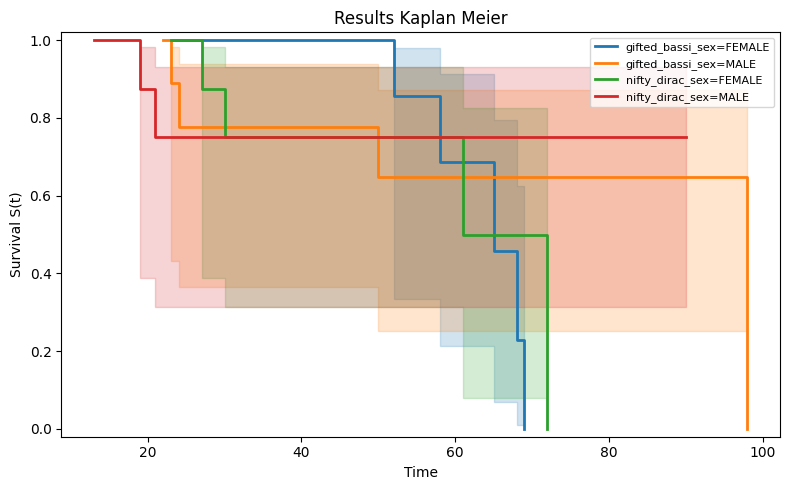

In [20]:
import pandas as pd
import matplotlib.pyplot as plt

names = sorted(list(result_global["kaplan_meier"].keys()))

# PREPARE FIG
fig = plt.figure(figsize=(8, 5))
ax = fig.add_subplot(111)
title = 'Results Kaplan Meier'

# COLORS per line
color_cycle = plt.cm.tab10.colors  # up to 10 distinct colors
name_colors = {name: color_cycle[i % len(color_cycle)] 
                   for i, name in enumerate(names)}

## PLOTTING
for name in names:

    color = name_colors[name]

    df = pd.DataFrame({
        col: pd.Series(values, dtype=float)
        for col, values in result_global["kaplan_meier"][name].items()
        if col != "cohort"
    })

    x = df["age"]
    S = df["survival_cdf"]

    # KM curve
    ax.step(x, S, where="post", label=name, color=color, linewidth=2)

    # CI interval
    if "ci_lower" in df and "ci_upper" in df:
        ax.fill_between(x, df["ci_lower"], df["ci_upper"], step="post",
                        alpha=0.2, color=color)

# FINISH FIG
ax.set_ylim(-0.02, 1.02)
ax.set_xlabel("Time")
ax.set_ylabel("Survival S(t)")
ax.set_title(title)
ax.legend(loc="upper right", fontsize=8)
fig.tight_layout()

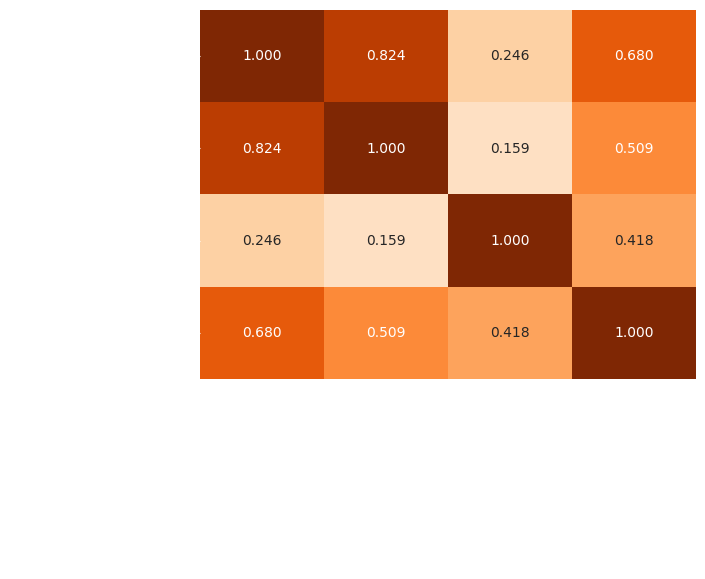

In [21]:
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

p_value_matrix_values = pd.DataFrame.from_dict(result_global["log_rank"]).fillna(1.0)


fig, ax = plt.subplots(facecolor="none")
ax.tick_params(colors="white")
ax.xaxis.label.set_color("white")
ax.yaxis.label.set_color("white")

sns.heatmap(
    p_value_matrix_values,
    annot=True,
    cmap="Oranges",
    ax=ax,
    fmt=".3f",
    cbar=False,
    vmin=0,
    vmax=1,
)
ax.set_facecolor("none")
fig.patch.set_alpha(0.0)